# Decision Trees

----

In [52]:
# Import libraries
import numpy as np
import pandas as pd

import pickle

import matplotlib.pyplot as plt

from sklearn.tree import export_text, plot_tree, DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, confusion_matrix, balanced_accuracy_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.inspection import PartialDependenceDisplay

## Prepare data

In [27]:
df = pd.read_csv("../data/GamingStudy_data_clean.csv")
df.head()

,SWL1,SWL2,SWL3,SWL4,SWL5,Hours,streams,SPIN1,SPIN2,SPIN3,...,Work_Unknown,Degree_High school diploma (or equivalent),Degree_Master (or equivalent),"Degree_Ph.D., Psy. D., MD (or equivalent)",Degree_Unknown,Playstyle_Offline Multiplayer,Playstyle_Other,Playstyle_Real Life Friends,Playstyle_Singleplayer,Playstyle_Strangers
0,7,7,7,5,7,25.0,2.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
1,6,6,6,3,5,5.0,5.0,2.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,1
2,5,2,6,7,6,9.0,2.0,2.0,2.0,2.0,...,0,1,0,0,0,0,0,1,0,0
3,2,4,6,6,3,7.0,4.0,0.0,1.0,3.0,...,0,0,1,0,0,0,0,0,0,1
4,2,2,1,3,2,25.0,35.0,0.0,2.0,1.0,...,0,1,0,0,0,0,0,0,0,1


In [28]:
df.shape

(10772, 60)

In [29]:
with open("../data/data.pkl", "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
FEATURES = data["FEATURES"]

In [30]:
X_train.head()

,SPIN2,SPIN13,SWL5,League_Unknown,Playstyle_Other,League_Other,League_Diamond,Playstyle_Singleplayer,SWL1,Work_Student at college / university,...,Narcissism,SPIN15,SWL3,whyplay_Improving,"Degree_Ph.D., Psy. D., MD (or equivalent)",SPIN11,Playstyle_Strangers,Platform_PC,League_Challenger,SWL2
10657,2.0,0.0,3,0,0,0,1,0,5,1,...,1.0,1.0,5,1,0,0.0,0,1,0,5
4174,3.0,3.0,1,0,0,0,0,0,1,1,...,4.0,4.0,2,1,0,4.0,1,1,0,1
1965,2.0,3.0,5,0,0,0,0,0,3,1,...,2.0,4.0,5,0,0,3.0,0,1,0,5
518,1.0,1.0,6,0,0,0,0,0,6,0,...,3.0,3.0,6,1,0,4.0,0,1,0,5
805,2.0,0.0,1,0,0,0,1,0,3,1,...,1.0,3.0,5,1,0,0.0,0,1,0,2


In [31]:
y_train.head()

10657    0
4174     1
1965     0
518      0
805      1
Name: GAD_T, dtype: int64

In [32]:
print(y_train.unique())
print(y_train.describe())

[0 1]
count    8536.000000
mean        0.171392
std         0.376873
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: GAD_T, dtype: float64


In [33]:
print(X_train.describe())

             SPIN2       SPIN13         SWL5  League_Unknown  Playstyle_Other  \
count  8536.000000  8536.000000  8536.000000     8536.000000      8536.000000   
mean      1.214738     0.537137     3.357896        0.106959         0.007849   
std       1.146012     0.941040     1.912792        0.309079         0.088252   
min       0.000000     0.000000     1.000000        0.000000         0.000000   
25%       0.000000     0.000000     2.000000        0.000000         0.000000   
50%       1.000000     0.000000     3.000000        0.000000         0.000000   
75%       2.000000     1.000000     5.000000        0.000000         0.000000   
max       4.000000     4.000000     7.000000        1.000000         1.000000   

       League_Other  League_Diamond  Playstyle_Singleplayer         SWL1  \
count   8536.000000     8536.000000             8536.000000  8536.000000   
mean       0.026710        0.121251                0.035965     3.734185   
std        0.161245        0.326438       

## Modeling

### Decision Tree

In [34]:
# fit decision tree model
tree_gaming_anxiety = DecisionTreeClassifier(random_state = 1)
tree_gaming_anxiety.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [35]:
tree_summary = export_text(tree_gaming_anxiety, feature_names=X_train.columns.tolist())
print(tree_summary)

|--- SWL3 <= 2.50
|   |--- SPIN13 <= 0.50
|   |   |--- SPIN15 <= 3.50
|   |   |   |--- SWL3 <= 1.50
|   |   |   |   |--- SPIN3 <= 2.50
|   |   |   |   |   |--- SPIN2 <= 3.50
|   |   |   |   |   |   |--- SWL2 <= 2.50
|   |   |   |   |   |   |   |--- Hours <= 36.50
|   |   |   |   |   |   |   |   |--- streams <= 14.00
|   |   |   |   |   |   |   |   |   |--- whyplay_Improving <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- SPIN16 <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |   |--- SPIN16 >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- whyplay_Improving >  0.50
|   |   |   |   |   |   |   |   |   |   |--- SWL1 <= 2.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |   |--- SWL1 >  2.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |  

In [36]:
importances = pd.DataFrame({'feature_name': X_train.columns, 'importance': tree_gaming_anxiety.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

                                  feature_name  importance
0                                         SWL3    0.116907
1                                       SPIN13    0.050877
2                                        Hours    0.049000
3                                       SPIN14    0.045594
4                                      streams    0.044531
5                                          Age    0.035951
6                                        SPIN2    0.035793
7                                       SPIN15    0.034304
8                                         SWL4    0.033591
9                                         SWL1    0.032179
10                                        SWL2    0.029026
11                                      SPIN16    0.027934
12                                      SPIN11    0.027839
13                                       SPIN5    0.027573
14                                      SPIN12    0.025731
15                                      SPIN17    0.0256

<span style="color:green"> From the importance table, SWL3 and SPIN13 appear to be the most important predictors. We can also see them at the top of the tree summary. </span>

In [37]:
# Calculate the accuracy of the decision tree on the test data
accuracy = tree_gaming_anxiety.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(accuracy*100))

Accuracy: 77.80%


<span style="color:green"> Accuracy score is 77.80% which means this model is decently accurate. </span>

### Tune Decision Tree

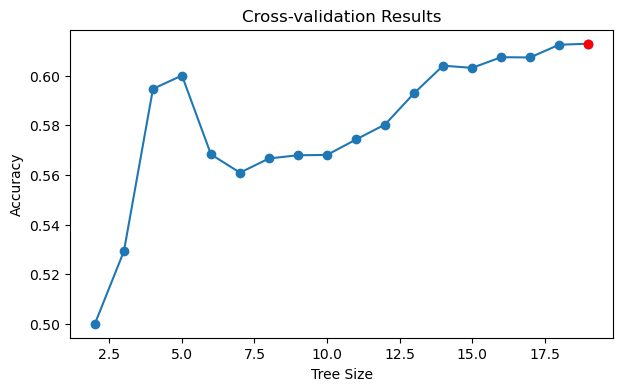

In [43]:
# cross-validation to determine optimal tree size
params = {'max_leaf_nodes': range(2, 20)}  
cv_gaming_anxiety = GridSearchCV(tree_gaming_anxiety, params, cv=20, scoring="balanced_accuracy")
cv_gaming_anxiety.fit(X_train, y_train)
cv_results = cv_gaming_anxiety.cv_results_

# find the best score for max leaf nodes
best_size = cv_gaming_anxiety.best_params_['max_leaf_nodes']
best_score = cv_gaming_anxiety.best_score_

# plot results of cross-validation
plt.figure(figsize=(7, 4))
plt.plot(cv_results["param_max_leaf_nodes"].data, cv_results["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results');

In [44]:
# fit pruned decision tree model
pruned_tree_gaming_anxiety = DecisionTreeClassifier(max_leaf_nodes=best_size, random_state=1)
pruned_tree_gaming_anxiety.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",19
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [45]:
pruned_tree_summary = export_text(pruned_tree_gaming_anxiety, feature_names=X_train.columns.tolist())
print(pruned_tree_summary)

|--- SWL3 <= 2.50
|   |--- SPIN13 <= 0.50
|   |   |--- SPIN15 <= 3.50
|   |   |   |--- SWL3 <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- SWL3 >  1.50
|   |   |   |   |--- class: 0
|   |   |--- SPIN15 >  3.50
|   |   |   |--- streams <= 7.00
|   |   |   |   |--- class: 0
|   |   |   |--- streams >  7.00
|   |   |   |   |--- class: 1
|   |--- SPIN13 >  0.50
|   |   |--- SPIN6 <= 3.50
|   |   |   |--- SWL3 <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- SWL3 >  1.50
|   |   |   |   |--- class: 0
|   |   |--- SPIN6 >  3.50
|   |   |   |--- SPIN16 <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- SPIN16 >  1.50
|   |   |   |   |--- class: 1
|--- SWL3 >  2.50
|   |--- SPIN14 <= 2.50
|   |   |--- SWL3 <= 4.50
|   |   |   |--- SPIN13 <= 0.50
|   |   |   |   |--- SPIN5 <= 3.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- SPIN5 >  3.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- SPIN13 >  0.50
|   |   |   |   |--- class: 0
|   |   |--- SWL3 >  4.50
|   |   

In [46]:
# Calculate the accuracy of the decision tree on the test data
accuracy_pruned = pruned_tree_gaming_anxiety.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(accuracy_pruned*100))

Accuracy: 83.65%


In [47]:
y_dt_pred = pruned_tree_gaming_anxiety.predict(X_test)

In [49]:
print(confusion_matrix(y_test, y_dt_pred))

[[1699   70]
 [ 279   87]]


<span style="color:green"> 1699 people who do not have anxiety (GAD_T < 10) were correctly classified as not anxious (TN). </span><br>
<span style="color:green"> 70 people who do not have anxiety were predicted that they do (FP). </span><br>
<span style="color:green"> 279 people who do have anxiety (GAD_T ≥ 10) were missed (FN). </span><br>
<span style="color:green"> 87 people who have anxiety were correctly identified. </span>

In [53]:
print(classification_report(y_test, y_dt_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_dt_pred))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      1769
           1       0.55      0.24      0.33       366

    accuracy                           0.84      2135
   macro avg       0.71      0.60      0.62      2135
weighted avg       0.81      0.84      0.81      2135

Balanced Accuracy: 0.5990672696438666


<span style="color:green"> Recall of .24 means that the model only catches 24% of anxious individuals. </span><br>
<span style="color:green"> Precision of 0.55 means that when the model predicts anxiety, it's correct about 55% of the time. </span><br>
<span style="color:green"> The balanced accuracy of about 60% means that the model is better than random guessing which would be about 50% </span>

### Random Forest Tuning

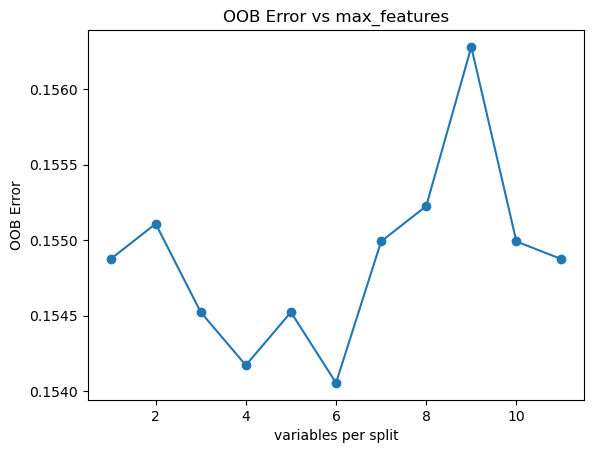

In [42]:
# Create plot to find optimal max_features
rf_gaming_anxiety = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=1)
oob_errors = []

for n in range(1, 12):
    rf_gaming_anxiety.set_params(max_features=n)
    
    rf_gaming_anxiety.fit(X_train, y_train)
    oob_error = 1 - rf_gaming_anxiety.oob_score_
    oob_errors.append(oob_error)

# plot error vs max_features
plt.plot(range(1, 12), oob_errors, marker='o')
plt.xlabel("variables per split")
plt.ylabel("OOB Error")
plt.title("OOB Error vs max_features")
plt.show()